# The Project
### Tristen Thompson

# Milestone 1

### Import necessary pakages and csv
The data in the csv was taken from Meteostat and it covers the weather in Maryville for the past 5 years from Meteostat. The data atrributes present are date, average tempurature, minimum temperature, maximum tempurature, precipitation, wind speed, and atmospheric pressure, aswell as other features that lack any data. There were attempts made to get more attributes from Meteostat and the NOAA, but the data's present in generated csv's were too irregular to consider.

In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from pandas.plotting import scatter_matrix

In [3]:
info = pd.read_csv("export.csv")
print(info.keys())
print(info.head())

Index(['date', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt',
       'pres', 'tsun'],
      dtype='object')
                  date  tavg  tmin  tmax  prcp  snow  wdir  wspd  wpgt  pres  \
0  2020-01-01 00:00:00   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
1  2020-01-02 00:00:00   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2  2020-01-03 00:00:00   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
3  2020-01-04 00:00:00   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
4  2020-01-05 00:00:00   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   

   tsun  
0   NaN  
1   NaN  
2   NaN  
3   NaN  
4   NaN  


### Initial relationships
First looks at relations from our weather data are not promising. Aside from a slightly positive correlation between precipitation and average temperature and a slight negative correlation between atmospheric pressure and average tempurature, there does not seem to be any interesting relationships. Turning to look at our features individually, we can see that the average tempurature ranges fairly far over the course of the year. Both wind speed and atmospheric pressure seem to form to right-skewed bell curves with wind speed skewing more than atmospheric pressure. Finally, looking at the precipitation histogram, it appears that there is little to no rain for most of the year with a few mild showers mixed in. Hopefully, after cleaning the data and adding in new features, we will discover something interesting.

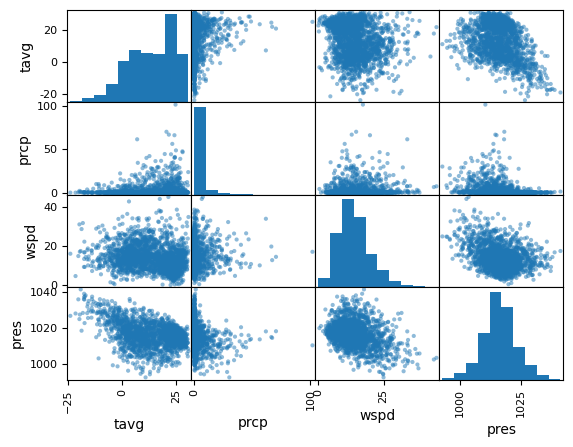

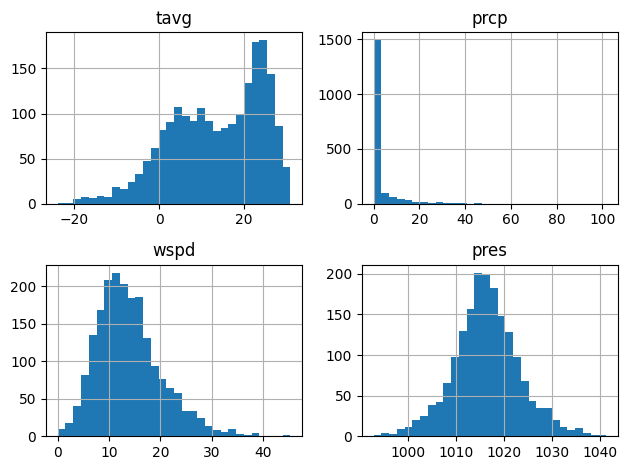

In [4]:
features = ['tavg', 'prcp', 'wspd', 'pres']
scatter_matrix(info[features])

info[features].hist(bins=30)
plt.tight_layout()
plt.show()

### Data Cleaning
There are three different objectives that will be met in the data cleaning. First, as you can see by looking at the head, there are gaps in the csv's rows devoid of data with only a date stamp present. We will remove instances that have only one attribute inorder to discard the large holes in the csv. Next, we have columns such as wind direction, wpgt, and tsun that lack any data. Naturally, we will remove these atributes from the csv as well. Finally, there are gaps present in the other wise complete attributes that will be filled by taking the average of a week's worth of data surrounding the hole in the attribute.

In [5]:
cleancsv = info.copy()

# Remove instances where there are less than two non-null attributes
cleancsv = cleancsv.dropna(thresh=2)

# Drop columns that contain few to none values
cleancsv.columns = cleancsv.columns.str.strip()
columnsToDrop = ['snow', 'wdir', 'wpgt', 'tsun']
cleancsv.drop(columns = [x for x in columnsToDrop if x in cleancsv.columns], inplace = True)

# Repair the holes in the csv
cleancsv[['prcp']] = cleancsv[['prcp']].fillna(0)
avg = cleancsv[['pres']].mean()
cleancsv[['pres']] = cleancsv[['pres']].fillna(avg)


columnsToClean = ['tavg', 'tmin', 'tmax', 'wspd']
for col in columnsToClean:
    if col in cleancsv.columns:
        for instance in cleancsv[cleancsv[col].isna()].index:
            start = max(instance-3, 0)
            end = min(instance+4, 2191)

            window = cleancsv.loc[start:end, col]

            avg = window.mean()
            cleancsv.loc[instance, col] = avg


print(cleancsv.head())

                    date  tavg  tmin  tmax  prcp  wspd         pres
167  2020-06-16 00:00:00  27.1  21.3  32.9   0.0  15.7  1016.376251
168  2020-06-17 00:00:00  26.2  20.0  32.0   0.0  20.6  1016.376251
169  2020-06-18 00:00:00  27.1  21.2  32.6   0.0  17.0  1016.376251
170  2020-06-19 00:00:00  22.2  21.2  23.6   0.0   7.0  1016.376251
171  2020-06-20 00:00:00  23.7  19.1  29.4   0.0   1.4  1016.376251


### New Attributes
We are going to create the following attributes. Month, so that we can track weather conditions accross different times of the year. Temperature range, to see what days vary the most in temperature. Storm index, which can tell us severity and potential impact of a storm.

In [6]:
# Temperture range
cleancsv['tempRange'] = cleancsv['tmax'] - cleancsv['tmin']

# Month of Weather instance
cleancsv['month'] = pd.to_datetime(cleancsv['date']).dt.month

# Storm Index
cleancsv['stormIndex'] = cleancsv['wspd'] * (1013 - cleancsv['pres'])

print(cleancsv.head())

                    date  tavg  tmin  tmax  prcp  wspd         pres  \
167  2020-06-16 00:00:00  27.1  21.3  32.9   0.0  15.7  1016.376251   
168  2020-06-17 00:00:00  26.2  20.0  32.0   0.0  20.6  1016.376251   
169  2020-06-18 00:00:00  27.1  21.2  32.6   0.0  17.0  1016.376251   
170  2020-06-19 00:00:00  22.2  21.2  23.6   0.0   7.0  1016.376251   
171  2020-06-20 00:00:00  23.7  19.1  29.4   0.0   1.4  1016.376251   

     tempRange  month  stormIndex  
167       11.6      6  -53.007147  
168       12.0      6  -69.550779  
169       11.4      6  -57.396274  
170        2.4      6  -23.633760  
171       10.3      6   -4.726752  


In [7]:
train_set, test_set = train_test_split(cleancsv, test_size=0.25, random_state=42)

### Feature Selection
We pick the features average temperature, wind speed, and precipitation to atmospheric pressure. The data set is fairly small in terms of features so it would be best to use all of the features we have. 

In [8]:
lin_reg = LinearRegression()
x = train_set[["tavg", "wspd", "prcp"]]
y = train_set[["pres"]]

lin_reg.fit(x,y)

score = lin_reg.score(x,y)

x_test = test_set[["tavg", "wspd", "prcp"]]
y_test = test_set[["pres"]]
y_pred = lin_reg.predict(x_test)

r2 = lin_reg.score(x_test, y_test)
MSE = mean_squared_error(y_test, y_pred)

print("r2 value is: ",str(r2))
print("Mean Square Error is: " + str(MSE))

r2 value is:  0.2731262455307315
Mean Square Error is: 30.64681822565699


In [9]:
lin_reg = LinearRegression()
x = train_set[["tavg", "wspd", "prcp", "stormIndex"]]
y = train_set[["pres"]]

lin_reg.fit(x,y)

score = lin_reg.score(x,y)

x_test = test_set[["tavg", "wspd", "prcp", "stormIndex"]]
y_test = test_set[["pres"]]
y_pred = lin_reg.predict(x_test)

r2 = lin_reg.score(x_test, y_test)
MSE = mean_squared_error(y_test, y_pred)

print("r2 value is: " + str(r2))
print("Mean Square Error is: " + str(MSE))

r2 value is: 0.861357259594681
Mean Square Error is: 5.845525220003528


### Conclusions
It was suprisingly difficult to find weather data for years before 2015. The weather data that I could get for free was full of holes for both government and nonprofit sites that I visited. The documentation for pandas has been unaccessable for a long amount of time. I also learned that the science behind weather prediction is more complex and varied than I had previously thought. In broard terms, I have learned how to utilize pandas to take in and proccess a csv file. Over the course of building my linear regression model and finding features that add into my data set, I have learned how to use windows to scan over my instances to better come up with values for the many missing values in my dataset. My thinking was that an average taken over the course of a week within the range of the missing values opposed to the average or median of a 5 year chunk of time. I also learned some of the more simple formulas for generating weather data as seen in my stormIndex feature. 

# Milestone 2

New Pacakage needed

In [10]:
from sklearn.tree import DecisionTreeClassifier

### Feature Selection

For my desision tree, we are going to select features tmax, tmin, tavg, wspd, prcp, and stormIndex to target the one of the features we made in milestone 1, month. We selected tmin, tavg, and tmax, because tempurature is one of the biggest differences between different months. The same can be said for stormIndex and its associated features prcp and wspd. As for the reason we are trying to predict months, I am courious if the effects of global warming have progressed to the point that my model will struggle to predict the months through weather data.

In [11]:
# Training features
x = train_set[["tmax", "tmin", "tavg", "wspd", "prcp", "stormIndex"]]
# Target feature
y = train_set["month"]

treeClassifier = DecisionTreeClassifier()

treeClassifier.fit(x,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

### Decision Tree Metrics

In [12]:
from sklearn.metrics import confusion_matrix
y_predicted = treeClassifier.predict(x)
matrix = confusion_matrix(y, y_predicted)
print(matrix)

[[113   0   0   0   0   0   0   0   0   0   0   0]
 [  0  98   0   0   0   0   0   0   0   0   0   0]
 [  0   0 113   0   0   0   0   0   0   0   0   0]
 [  0   0   0 117   0   0   0   0   0   0   0   0]
 [  0   0   0   0 119   0   0   0   0   0   0   0]
 [  0   0   0   0   0 117   0   0   0   0   0   0]
 [  0   0   0   0   0   0 143   0   0   0   0   0]
 [  0   0   0   0   0   0   0 141   0   0   0   0]
 [  0   0   0   0   0   0   0   0 146   0   0   0]
 [  0   0   0   0   0   0   0   0   0 138   0   0]
 [  0   0   0   0   0   0   0   0   0   0 135   0]
 [  0   0   0   0   0   0   0   0   0   0   0 135]]


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print ("Accuracy is ", accuracy_score(y, y_predicted))

# We have to specify how to combine for the multiclassifications
print ("Precision is ", precision_score(y, y_predicted, average="weighted"))
print ("Sensitivity is ", recall_score(y, y_predicted, average="weighted"))
print ("F1 is ", f1_score(y, y_predicted, average="weighted"))


Accuracy is  1.0
Precision is  1.0
Sensitivity is  1.0
F1 is  1.0


In [14]:
score = treeClassifier.score(x,y)

x_test = test_set[["tmax", "tmin", "tavg", "wspd", "prcp", "stormIndex"]]
y_test = test_set[["month"]]
y_pred = treeClassifier.predict(x_test)

r2 = treeClassifier.score(x_test, y_test)
MSE = mean_squared_error(y_test, y_pred)

print("r2 value is: " + str(r2))
print("Mean Square Error is: " + str(MSE))

r2 value is: 0.24703557312252963
Mean Square Error is: 21.845849802371543


In [15]:
from sklearn.model_selection import KFold
validation_accuracy = []
validation_f1 =[]
fold_and_validate = KFold(n_splits=5, shuffle=True, random_state=145)
for train_set_indices, validation_set_indices in fold_and_validate.split(x):
    cv_train_set = x.iloc[train_set_indices]
    cv_train_target = y.iloc[train_set_indices]
    #print(cv_train_set)
    
    cv_decision_tree = DecisionTreeClassifier()
    cv_decision_tree.fit(cv_train_set, cv_train_target)
    
    cv_xvalidation = x.iloc[validation_set_indices]
    cv_y_true = y.iloc[validation_set_indices]
    cv_y_predicted = cv_decision_tree.predict(cv_xvalidation)
    
    cv_accuracy_score = accuracy_score(cv_y_true, cv_y_predicted)
    cv_f1_score = f1_score(cv_y_true, cv_y_predicted,  average="weighted")
    
    validation_accuracy.append(cv_accuracy_score)
    validation_f1.append(cv_f1_score)
    
print("Cross validation accuracies are: ", validation_accuracy)
print("Cross validation f1 scores  are: ", validation_f1)

Cross validation accuracies are:  [0.3102310231023102, 0.30033003300330036, 0.30363036303630364, 0.30363036303630364, 0.2871287128712871]
Cross validation f1 scores  are:  [0.30919750859265294, 0.30316739299696993, 0.30020888375782057, 0.2966541428117014, 0.2912277529924185]


### Initial results

As made obvious by our confusion matrix and driven home by the perfect scores in Accuracy, Precision, and Sensitivity, our model was overfitting. Once we performed Cross validation on our set, it turned out that the decision tree holds an accuracy and f1 score hovering around 30-25%. The calculated r2 value, 0.249, also backs up this percentage. While that seems pretty bad, those percentages are significantly better than random guessing. The model might perform better if it were to be guessing seasons than months, but either way the model could definitely be improved

# SVM

In [16]:
from sklearn.svm import SVC
x = cleancsv[["tmax", "tmin", "tavg", "wspd", "prcp", "stormIndex"]]
y = cleancsv["month"]

svm_classifier = SVC(kernel="rbf")
svm_classifier.fit(x,y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [17]:
y_predicted = svm_classifier.predict(x)
matrix = confusion_matrix(y, y_predicted)
print(matrix)

print ("Accuracy is ", accuracy_score(y, y_predicted))

# We have to specify how to combine for the multiclassifications
print ("Precision is ", precision_score(y, y_predicted, average="weighted"))
print ("Sensitivity is ", recall_score(y, y_predicted, average="weighted"))
print ("F1 is ", f1_score(y, y_predicted, average="weighted"))


[[ 62   1  10   6   0   0   0   0   0   0  11  65]
 [ 47   7  11  10   1   0   0   0   0   0  29  36]
 [ 16   0  17  28   3   0   0   0   2  11  58  18]
 [  3   1   8  44  11   3   0   1  10  23  43   3]
 [  0   0   3  23  12  19  20   6  34  31   7   0]
 [  0   0   0   5   0  47  77  21  11   4   0   0]
 [  0   0   0   0   0  12 123  44   5   2   0   0]
 [  0   0   0   0   0  17  83  54  25   7   0   0]
 [  0   0   2   1   2  14  47  26  66  19   3   0]
 [  6   0   7  20  11   6   8   7  34  45  33   9]
 [ 27   1  12  11   4   0   0   0   2  25  75  23]
 [ 30   3  14   9   0   0   0   0   1   1  36  90]]
Accuracy is  0.3176645225136071
Precision is  0.32671297848458475
Sensitivity is  0.3176645225136071
F1 is  0.2943486201333813


In [18]:
from sklearn.model_selection import KFold
validation_accuracy = []
validation_f1 =[]
fold_and_validate = KFold(n_splits=5, shuffle=True, random_state=145)
for train_set_indices, validation_set_indices in fold_and_validate.split(x):
    cv_train_set = x.iloc[train_set_indices]
    cv_train_target = y.iloc[train_set_indices]
    
    cv_svc = SVC()
    cv_svc.fit(cv_train_set, cv_train_target)
    
    cv_xvalidation = x.iloc[validation_set_indices]
    cv_y_true = y.iloc[validation_set_indices]
    cv_y_predicted = cv_svc.predict(cv_xvalidation)
    
    cv_accuracy_score = accuracy_score(cv_y_true, cv_y_predicted)
    cv_f1_score = f1_score(cv_y_true, cv_y_predicted,  average="weighted")
    validation_accuracy.append(cv_accuracy_score)
    validation_f1.append(cv_f1_score)
    
print("Cross validation accuracies are: ", validation_accuracy)
print("Cross validation f1 scores  are: ", validation_f1)

Cross validation accuracies are:  [0.2839506172839506, 0.27722772277227725, 0.30445544554455445, 0.28465346534653463, 0.2871287128712871]
Cross validation f1 scores  are:  [0.2705657135698293, 0.2529689410404221, 0.27117782873114415, 0.2720973898198983, 0.2555862851103791]


# SVM vs. Decision Tree

Unexpecedly, the Decision Tree performed nearly as well as SVM in the validation sets. Despite the Decision Tree Classifier overfitting the data at first, the validation set had accuracies that surrpassed the highest accuracies and f1 scores. SVM was more consistent with its scores on the other hand with differences in hundredths and the Decision Tree having differences in the range of tenths. It is also worth noting that SVM did not overfit itself on the data in the inital output. Overall, I would say that there is a correlation between my weather data and the month in which it occurs and perhaps the truely drastic weather changes have yet to occur in the world from global warming.

# Final Thoughts

There were a lot of things learned over the course of this project. As previously mentioned, it was surprisingly difficult to find Maryville weather data for years before 2015, most likely due to the small size of the northwest Missouri regional airport (kevu) which provided the data that was used in this project. I learned that there are many resources out there for data collection, like the national Oceanic and Atmospheric Administration and non-profit sites like Metostat and Kaggle, which inspired some of my created features. I also learned how some of the more basic formulas behind certain weather data types. In broad terms, I have learned how to utilize pandas to take in and process a csv file as well as how to use various models and features from sklearn. Over the course of building my linear regression model and finding features that add into my data set, I also learned how to use windows to supplement more accurate data for missing values in my data cleaning section. Moving onto the Decision Trees and SVM utilizations, I was able to build off of the concepts we learned in class to create a confusion matrix as well as compute the values associated with it. That knowledge allowed me to better gauge the results from the Decision Tree classifiers and SVM. Ultimately, I was able draw some connections between my cleaned data to atmospheric pressure and created a Decision Tree that produces better predictions on what month it is with given weather data over random guessing.

The relativly high distortion value leads me to think that my instances are very spread out in their attribute, meaning the culsters that I managed to generate should be taken with a grain of salt. That being said, Cluster 0 represents relativly warm, calm, and/or rainy days. Cluster 1 represents metorogically active days with high winds, rain, and storm indexes. Cluster 2 represents cold, calm, and/or dry days. Initail PCA results look strong. After reducing my 6 components down to 2, the condensed components managed to retain roughly 75% of the variance. Comparing the K-means graphs after PCA along with my cluster graph and conclusions from culter profiles, I belive that my data can be accuratly gathered into three clusters consisting of mild warm weather, extreme weather difined by high winds and percipitation, and mild cold weather. These clusters belong to clusters 0, 1, and 2 respectivly.


After comuputing the number of outliers in my data set, it appears about 5 percent of my data is made up of outliers. While this is fairly high for most data sets, my data comes from weather data in the mid-west which is know to have chaotic and rapidly changing weather conditions. This leads me to believe that the percentage of outliers is acceptable. Unexpecedly, the Decision Tree performed nearly as well as SVM in the validation sets. Despite the Decision Tree Classifier overfitting the data at first, the validation set had accuracies that surrpassed the highest accuracies and f1 scores. SVM was more consistent with its scores on the other hand with differences in hundredths and the Decision Tree having differences in the range of tenths. It is also worth noting that SVM did not overfit itself on the data in the inital output. Overall, I would say that there is a correlation between my weather data and the month in which it occurs and perhaps the truely drastic weather changes have yet to occur in the world from global warming. Neural Network scored higher in both accuracy and f1 scores, but only by a margin of 0.01. Both models performed very well with scores in the high nineties which is a massive improvement compared to the K-fold, desicion trees, and linear regression models previously used. Overall, both models outperform simpler clustering-based approaches in predictive accuracy, demonstrating the benefit of supervised learning for classification tasks.

# Milestone 3

## Kmeans and Clusters

                    date  tavg  tmin  tmax  prcp  wspd         pres  \
167  2020-06-16 00:00:00  27.1  21.3  32.9   0.0  15.7  1016.376251   
168  2020-06-17 00:00:00  26.2  20.0  32.0   0.0  20.6  1016.376251   
169  2020-06-18 00:00:00  27.1  21.2  32.6   0.0  17.0  1016.376251   
170  2020-06-19 00:00:00  22.2  21.2  23.6   0.0   7.0  1016.376251   
171  2020-06-20 00:00:00  23.7  19.1  29.4   0.0   1.4  1016.376251   

     tempRange  month  stormIndex  Cluster  
167       11.6      6  -53.007147        0  
168       12.0      6  -69.550779        0  
169       11.4      6  -57.396274        0  
170        2.4      6  -23.633760        0  
171       10.3      6   -4.726752        0  


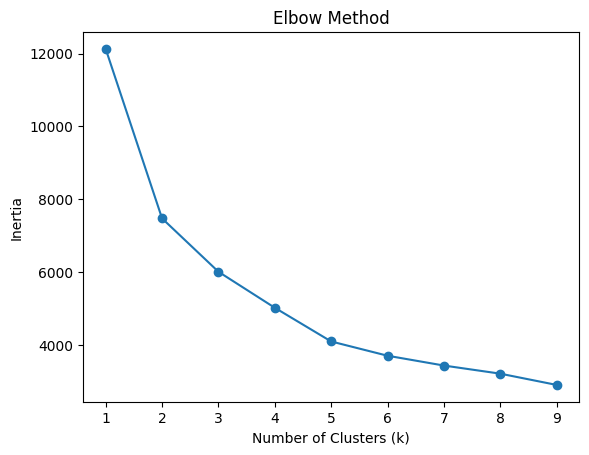

In [19]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = cleancsv[["tmax", "tmin", "tavg", "wspd", "prcp", "stormIndex"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
clusters = kmeans.labels_

# Add cluster ino to instances
cleancsv["Cluster"] = clusters
print(cleancsv.head())

# Use Elbow Method to find ideal number of clusters
inertia = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [20]:
# Kmeans Stats
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

print("The distortion is ", kmeans.inertia_)
RMS_average = math.sqrt(kmeans.inertia_ / len(X))
print("Averaging and taking the square root gives ", RMS_average)

The distortion is  7476.9147792535905
Averaging and taking the square root gives  1.9234374097433462


In [21]:
# Discovering kmeans cluster Relations
cluster_profile = cleancsv.groupby("Cluster")[[
    "tmax", "tmin", "tavg", "wspd", "prcp", "stormIndex"
]].mean()

print(cluster_profile)

              tmax       tmin       tavg       wspd       prcp  stormIndex
Cluster                                                                   
0        28.096410  16.889300  22.332450  11.016119   1.398940  -28.679063
1        20.118280  10.232975  14.942294  21.965950  10.979211  123.216267
2         7.864402  -2.305328   2.568461  14.552441   0.505757  -96.157215


The relativly high distortion value leads me to think that my instances are very spread out in their attribute, meaning the culsters that I managed to generate should be taken with a grain of salt. That being said, Cluster 0 represents relativly warm, calm, and/or rainy days. Cluster 1 represents metorogically active days with high winds, rain, and storm indexes. Cluster 2 represents cold, calm, and/or dry days.

## PCA

In [22]:
from sklearn.decomposition import PCA

X = cleancsv[["tmax", "tmin", "tavg", "wspd", "prcp", "stormIndex"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reducing the number of component to 2 for the purposes of better visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
print("Total variance retained:", sum(pca.explained_variance_ratio_))

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
print(pca_df.head())

[0.53131832 0.21771963]
Total variance retained: 0.7490379498920484
        PC1       PC2
0  1.881393 -0.330758
1  1.591619  0.128357
2  1.826075 -0.211466
3  1.427638 -1.008108
4  1.828043 -1.551700


### PCA Results

Initail PCA results look strong. After reducing my 6 components down to 2, the condensed components managed to retain roughly 75% of the variance. 

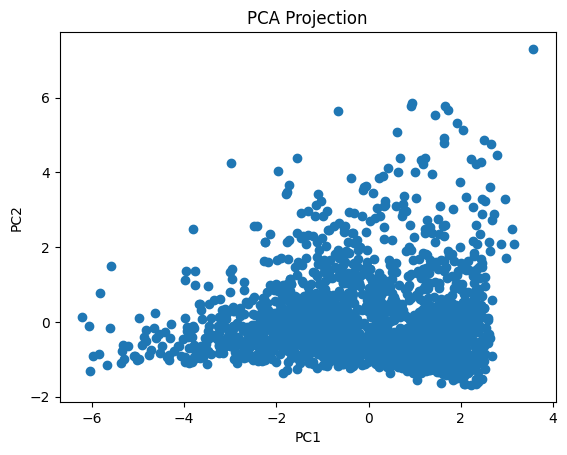

In [23]:
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

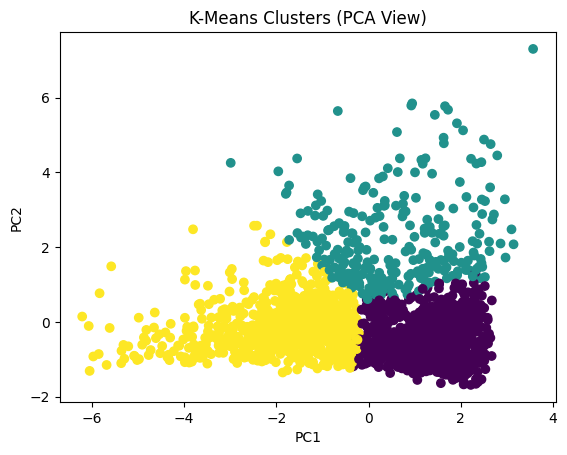

In [24]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (PCA View)")
plt.show()

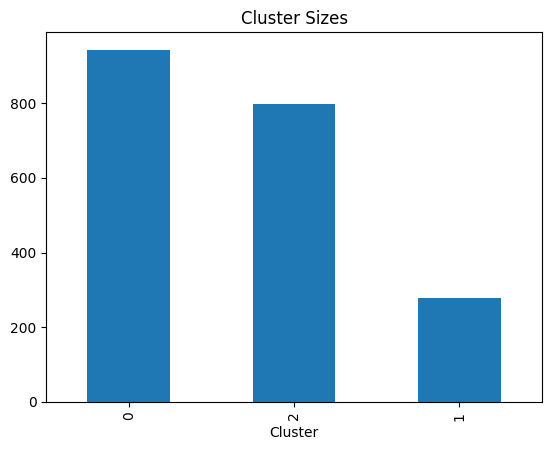

In [25]:
cleancsv["Cluster"].value_counts().plot(kind="bar")
plt.title("Cluster Sizes")
plt.show()

Comparing the K-means graphs after PCA along with my cluster graph and conclusions from culter profiles, I belive that my data can be accuratly gathered into three clusters consisting of mild warm weather, extreme weather difined by high winds and percipitation, and mild cold weather. These clusters belong to clusters 0, 1, and 2 respectivly.

## Outliers by Statistical Method

In [26]:
from scipy import stats

z_scores = np.abs(stats.zscore(X))
outliers_z = (z_scores > 3).any(axis=1)

cleancsv["Outlier_Z"] = outliers_z

cleancsv["Outlier_Z"] = cleancsv["Outlier_Z"].astype(str).str.lower().map({"true": 1, "false": 0})

total = cleancsv["Outlier_Z"].sum()

print("Total Outliers: ",total)
print("Total number of instances",len(cleancsv))
print("Percent of Outliers in dataset", total/len(cleancsv))

Total Outliers:  104
Total number of instances 2021
Percent of Outliers in dataset 0.051459673428995545


After comuputing the number of outliers in my data set, it appears about 5 percent of my data is made up of outliers. While this is fairly high for most data sets, my data comes from weather data in the mid-west which is know to have chaotic and rapidly changing weather conditions. This leads me to believe that the percentage of outliers is acceptable.

## Random Forest vs Neural Network

In [27]:
from sklearn.ensemble import RandomForestClassifier
# Random Tree
X_rf = X_scaled
y = cleancsv["Cluster"]

X_train, X_test, y_train, y_test = train_test_split(X_rf, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# Neural Network
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(hidden_layer_sizes=(50,), max_iter=2000, random_state=42)
nn.fit(X_train, y_train)

nn_pred = nn.predict(X_test)

In [28]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest F1:", f1_score(y_test, rf_pred, average='weighted'))

print("Neural Network Accuracy:", accuracy_score(y_test, nn_pred))
print("Neural Network F1:", f1_score(y_test, nn_pred, average='weighted'))

Random Forest Accuracy: 0.9753086419753086
Random Forest F1: 0.9752498626048139
Neural Network Accuracy: 0.9851851851851852
Neural Network F1: 0.9851737789889259


Neural Network scored higher in both accuracy and f1 scores, but only by a margin of 0.01. Both models performed very well with scores in the high nineties which is a massive improvement compared to the K-fold, desicion trees, and linear regression models previously used. Overall, both models outperform simpler clustering-based approaches in predictive accuracy, demonstrating the benefit of supervised learning for classification tasks.

In [29]:
print(cleancsv.keys())

Index(['date', 'tavg', 'tmin', 'tmax', 'prcp', 'wspd', 'pres', 'tempRange',
       'month', 'stormIndex', 'Cluster', 'Outlier_Z'],
      dtype='object')
